In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)



In [2]:
import os
print(os.path.exists('/root/.keras/datasets/cifar-10-batches-py'))

False


In [3]:

#Load the dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Train shape:", x_train.shape, "Test shape:", x_test.shape)





170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1709s 10us/step
Train shape: (50000, 32, 32, 3) Test shape: (10000, 32, 32, 3)


In [7]:
import matplotlib as mpl
import matplotlib.font_manager as fm

# Path to your uploaded font
font_path = "/times.ttf"      # Change if the filename is different

# Register the font
fm.fontManager.addfont(font_path)

# Get the font name stored inside the TTF
font_name = fm.FontProperties(fname=font_path).get_name()
print("Loaded Font:", font_name)

# Set it as the default font
mpl.rcParams['font.family'] = font_name
mpl.rcParams['font.size'] = 16
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 16
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['legend.fontsize'] = 16

def save_eps_or_pdf(filename, dpi=600, max_size_kb=100):

    eps_name = filename + ".eps"

    plt.savefig(
        eps_name,
        format='eps',
        dpi=dpi,
        bbox_inches='tight'
    )

    size_kb = os.path.getsize(eps_name) / 1024

    if size_kb > max_size_kb:
        os.remove(eps_name)
        pdf_name = filename + ".pdf"
        plt.savefig(
            pdf_name,
            format='pdf',
            bbox_inches='tight'
        )
        print(f"{pdf_name} saved (EPS was {size_kb:.1f} KB)")
    else:
        print(f"{eps_name} saved ({size_kb:.1f} KB)")

Loaded Font: Times New Roman


class_distribution.eps saved (31.6 KB)


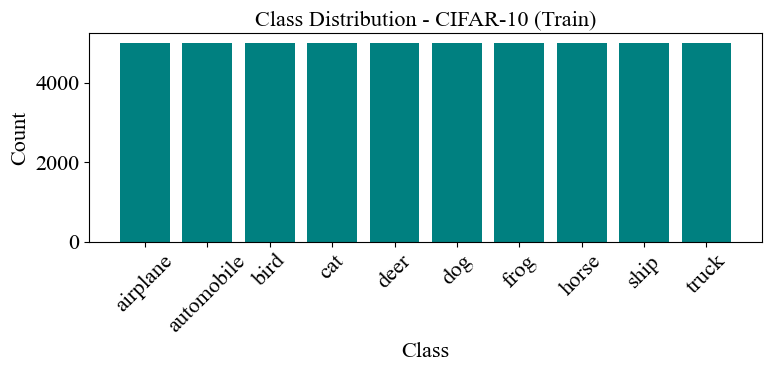

In [ ]:

# 2. Class distribution

unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([class_names[i] for i in unique], counts, color='teal')
plt.title("Class Distribution - CIFAR-10 (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
save_eps_or_pdf("class_distribution")

plt.show()


sample_images.pdf saved (EPS was 62428.0 KB)


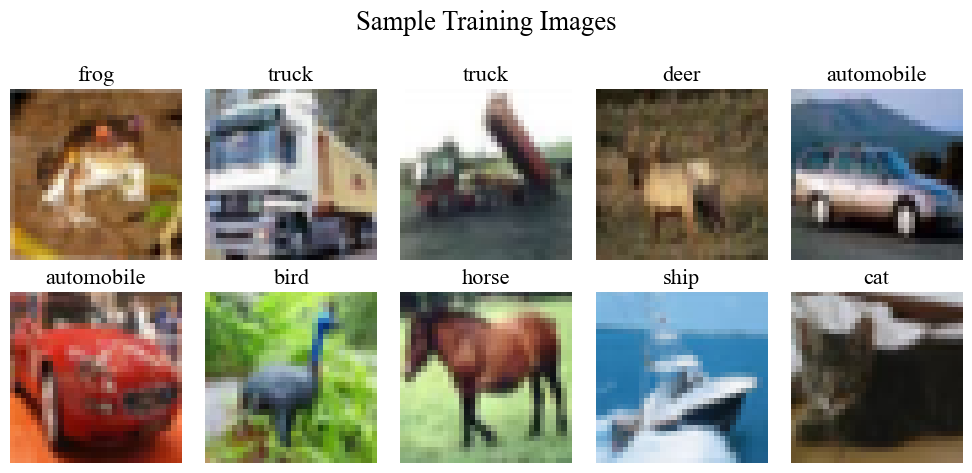

In [ ]:

# 3. Sample images

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()

save_eps_or_pdf("sample_images")

plt.show()

In [ ]:

# 4. Build CNN model

def build_cnn(kernel_size=(3, 3), pool_type='max', filters=(32, 64, 128),
              optimizer='adam', padding='same'):
    model = models.Sequential()

    model.add(layers.Conv2D(filters[0], kernel_size, padding=padding,
                             activation='relu', input_shape=(32, 32, 3), name='conv1'))
    model.add(layers.MaxPooling2D((2, 2)) if pool_type == 'max' else layers.AveragePooling2D((2, 2)))

    model.add(layers.Conv2D(filters[1], kernel_size, padding=padding,
                             activation='relu', name='conv2'))
    model.add(layers.MaxPooling2D((2, 2)) if pool_type == 'max' else layers.AveragePooling2D((2, 2)))

    model.add(layers.Conv2D(filters[2], kernel_size, padding=padding,
                             activation='relu', name='conv3'))
    model.add(layers.MaxPooling2D((2, 2)) if pool_type == 'max' else layers.AveragePooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn()
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# 5. Trainable parameters per conv layer

print("\nLayer-wise trainable parameters:")
for layer in model.layers:
    if layer.count_params() > 0:
        print(f"{layer.name:15s} -> {layer.count_params():,} params")


Layer-wise trainable parameters:
conv1           -> 896 params
conv2           -> 18,496 params
conv3           -> 73,856 params
dense           -> 262,272 params
dense_1         -> 1,290 params


In [ ]:



# 6. Train the model

BATCH_SIZE = 64
EPOCHS = 20

history = model.fit(x_train, y_train_cat,
                     batch_size=BATCH_SIZE,
                     epochs=EPOCHS,
                     validation_split=0.2,
                     verbose=1)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.3572 - loss: 1.7303 - val_accuracy: 0.5204 - val_loss: 1.3405
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5120 - loss: 1.3539 - val_accuracy: 0.5894 - val_loss: 1.1411
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5826 - loss: 1.1747 - val_accuracy: 0.6446 - val_loss: 1.0206
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6343 - loss: 1.0431 - val_accuracy: 0.6799 - val_loss: 0.9025
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6643 - loss: 0.9618 - val_accuracy: 0.6967 - val_loss: 0.8613
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6883 - loss: 0.8960 - val_accuracy: 0.7055 - val_loss: 0.8497
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7105 - loss: 0.8359 - val_accuracy: 0.6942 - val_loss: 0.8853
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7263 - loss: 0.7836 - val_accuracy: 0

training_curves.eps saved (32.4 KB)


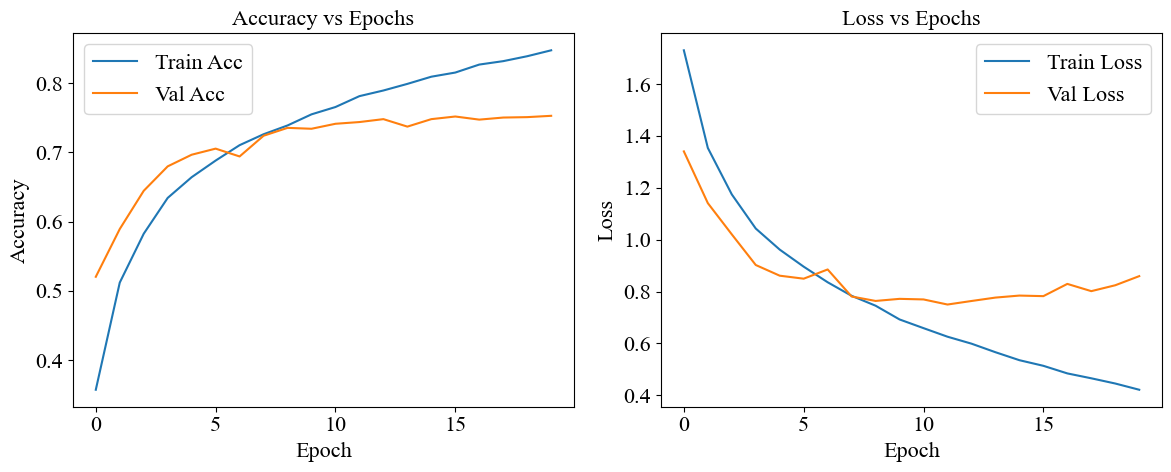

In [ ]:



# 7. Training curves

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
save_eps_or_pdf("training_curves")

plt.show()

In [ ]:


# 8. Evaluate on test set

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Test Accuracy: 0.7438
Test Loss: 0.8965
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Precision: 0.7453
Recall: 0.7438
F1-score: 0.7420

Classification Report:

              precision    recall  f1-score   support

    airplane       0.80      0.78      0.79      1000
  automobile       0.84      0.89      0.86      1000
        bird       0.62      0.65      0.64      1000
         cat       0.61      0.47      0.53      1000
        deer       0.61      0.79      0.69      1000
         dog       0.67      0.61      0.64      1000
        frog       0.78      0.82      0.80      1000
       horse       0.82      0.76      0.79      1000
        ship       0.88      0.83      0.85      1000
       truck       0.83      0.83      0.83      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



confusion_matrix.pdf saved (EPS was 1712.0 KB)


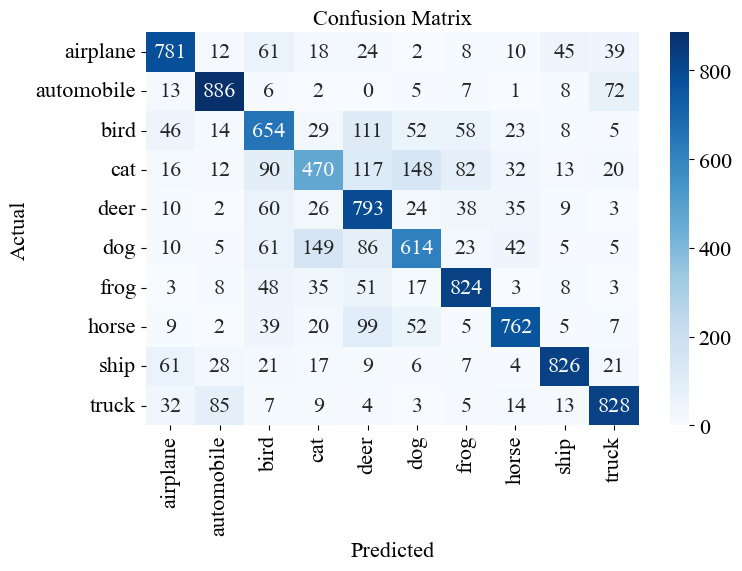

In [ ]:



# 9. Confusion Matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
save_eps_or_pdf("confusion_matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 938ms/step
feature_maps_conv1.pdf saved (EPS was 50912.8 KB)


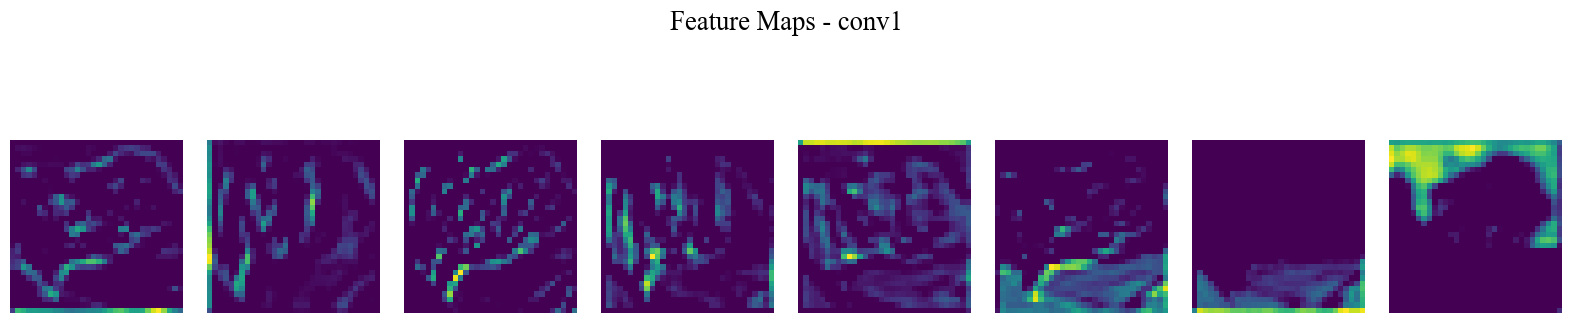

feature_maps_conv2.pdf saved (EPS was 50912.9 KB)


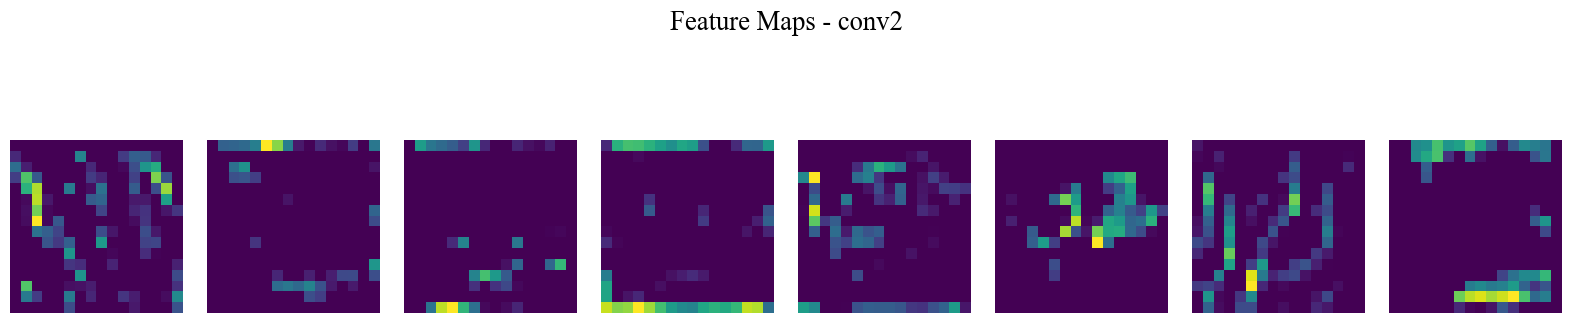

feature_maps_conv3.pdf saved (EPS was 50913.2 KB)


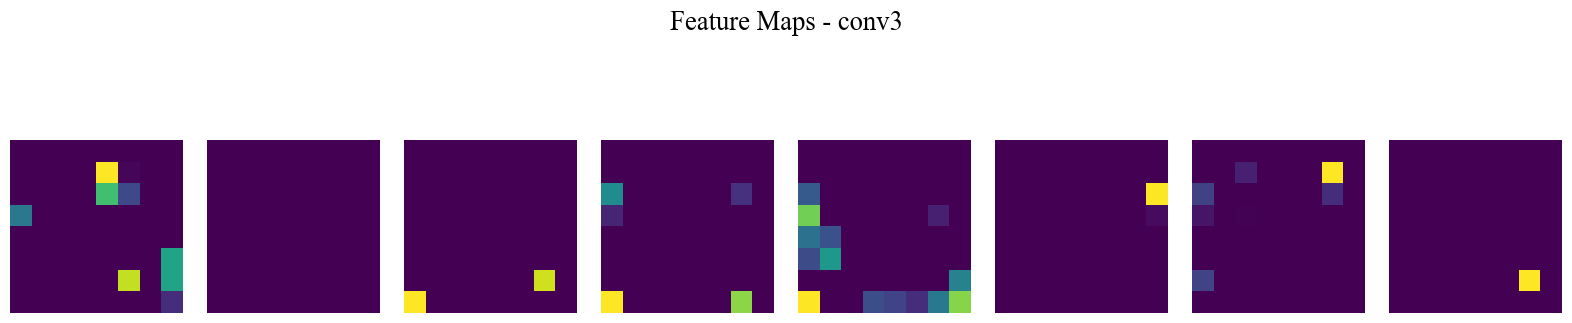

In [ ]:



# 10. Feature map visualization

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in model.layers if "conv" in layer.name]

activation_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=layer_outputs
)
img = x_test[0:1]
activations = activation_model.predict(img)

for layer_name, activation in zip(['conv1', 'conv2', 'conv3'], activations):
    n_features = min(8, activation.shape[-1])
    plt.figure(figsize=(16, 4))
    for i in range(n_features):
        plt.subplot(1, n_features, i + 1)
        plt.imshow(activation[0, :, :, i], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f"Feature Maps - {layer_name}")
    plt.tight_layout()

    save_eps_or_pdf(f"feature_maps_{layer_name}")

    plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3708 - loss: 1.7152 - val_accuracy: 0.5363 - val_loss: 1.3040
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5239 - loss: 1.3240 - val_accuracy: 0.6183 - val_loss: 1.0932
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5904 - loss: 1.1513 - val_accuracy: 0.6394 - val_loss: 1.0108
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6361 - loss: 1.0375 - val_accuracy: 0.6645 - val_loss: 0.9876
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6728 - loss: 0.9382 - val_accuracy: 0.7047 - val_loss: 0.8495
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6952 - loss: 0.8678 - val_accuracy: 0.7110 - val_loss: 0.8321
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7199 - loss: 0.8015 - val_accuracy: 0.7175 - val_loss: 0.8048
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7351 - loss: 0.7492 - val_accuracy: 0.


--- Pooling Comparison ---
Max Pooling -> Test Accuracy: 0.7384
Avg Pooling -> Test Accuracy: 0.7391
pooling_comparison.eps saved (44.3 KB)


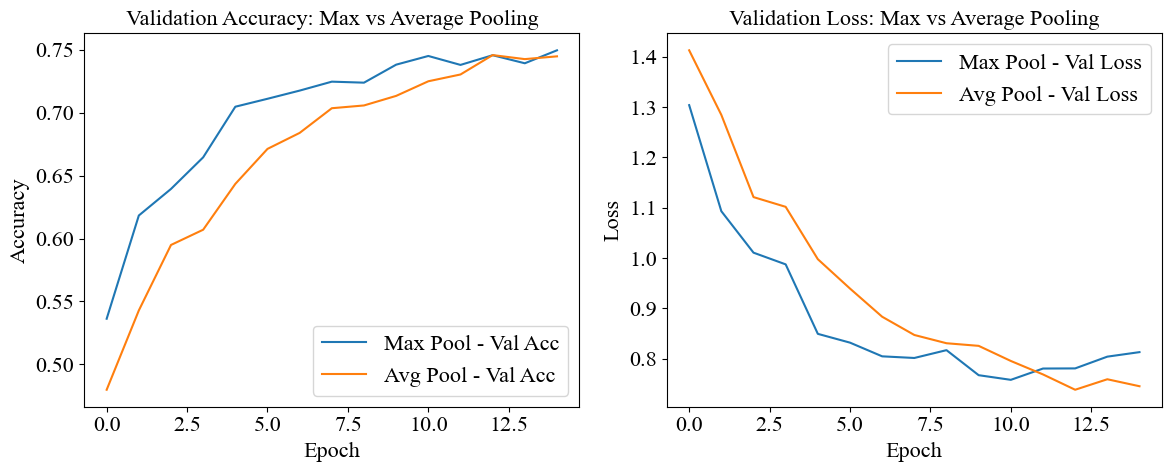

In [ ]:
import time


# Q4: Max Pooling vs Average Pooling comparison

pooling_results = {}
pooling_histories = {}

for pool in ['max', 'avg']:
    model_p = build_cnn(pool_type=pool)
    hist_p = model_p.fit(x_train, y_train_cat, batch_size=64, epochs=15,
                          validation_split=0.2, verbose=1)
    test_loss_p, test_acc_p = model_p.evaluate(x_test, y_test_cat, verbose=0)
    pooling_results[pool] = test_acc_p
    pooling_histories[pool] = hist_p

print("\n--- Pooling Comparison ---")
for k, v in pooling_results.items():
    print(f"{k.capitalize()} Pooling -> Test Accuracy: {v:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(pooling_histories['max'].history['val_accuracy'], label='Max Pool - Val Acc')
plt.plot(pooling_histories['avg'].history['val_accuracy'], label='Avg Pool - Val Acc')
plt.title("Validation Accuracy: Max vs Average Pooling")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(pooling_histories['max'].history['val_loss'], label='Max Pool - Val Loss')
plt.plot(pooling_histories['avg'].history['val_loss'], label='Avg Pool - Val Loss')
plt.title("Validation Loss: Max vs Average Pooling")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
save_eps_or_pdf("pooling_comparison")
plt.show()


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3656 - loss: 1.7309 - val_accuracy: 0.4992 - val_loss: 1.4054
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4974 - loss: 1.3973 - val_accuracy: 0.5615 - val_loss: 1.2226
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5586 - loss: 1.2329 - val_accuracy: 0.5837 - val_loss: 1.1660
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6015 - loss: 1.1234 - val_accuracy: 0.6450 - val_loss: 1.0001
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6333 - loss: 1.0448 - val_accuracy: 0.6686 - val_loss: 0.9414
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6617 - loss: 0.9731 - val_accuracy: 0.6895 - val_loss: 0.8695
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6788 - loss: 0.9168 - val_accuracy: 0.7005 - val_loss: 0.8602
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6961 - loss: 0.8686 - val_accuracy: 0.

filters_comparison.eps saved (39.0 KB)


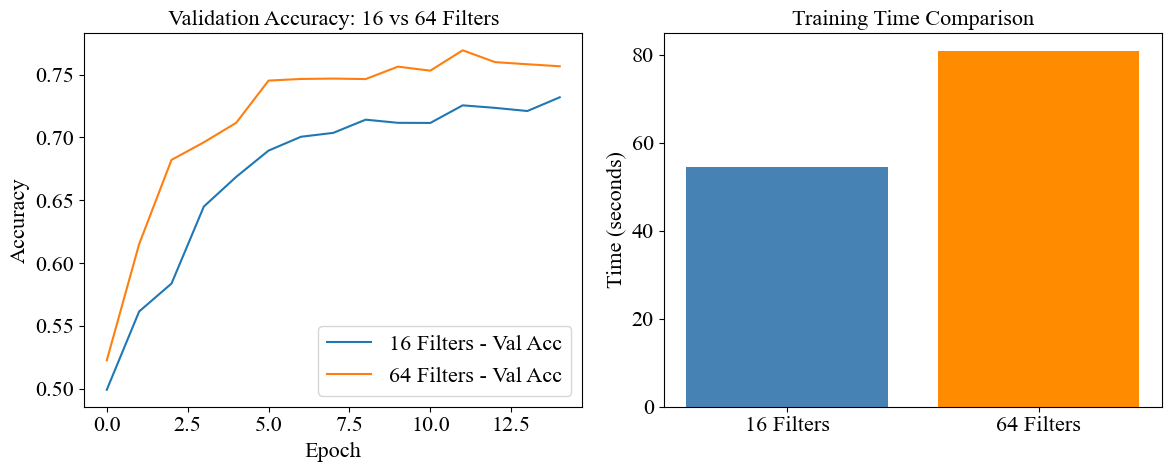

In [ ]:

# Q5: Filter count comparison (16 vs 64) - accuracy & time

filter_results = {}
filter_histories = {}
filter_times = {}

for f in [16, 64]:
    model_f = build_cnn(filters=(f, f*2, f*4))
    start = time.time()
    hist_f = model_f.fit(x_train, y_train_cat, batch_size=64, epochs=15,
                          validation_split=0.2, verbose=1)
    elapsed = time.time() - start
    test_loss_f, test_acc_f = model_f.evaluate(x_test, y_test_cat, verbose=0)

    filter_results[f] = test_acc_f
    filter_histories[f] = hist_f
    filter_times[f] = elapsed

print("\n--- Filter Count Comparison ---")
for f in [16, 64]:
    print(f"Filters={f} -> Test Accuracy: {filter_results[f]:.4f}, "
          f"Training Time: {filter_times[f]:.2f}s")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(filter_histories[16].history['val_accuracy'], label='16 Filters - Val Acc')
plt.plot(filter_histories[64].history['val_accuracy'], label='64 Filters - Val Acc')
plt.title("Validation Accuracy: 16 vs 64 Filters")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.bar(['16 Filters', '64 Filters'], [filter_times[16], filter_times[64]],
        color=['steelblue', 'darkorange'])
plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")

plt.tight_layout()
save_eps_or_pdf("filters_comparison")
plt.show()

In [8]:
def build_cnn_activation(activation='relu'):
    model = models.Sequential()

    model.add(layers.Conv2D(32, (3, 3), padding='same',
                             activation=activation, input_shape=(32, 32, 3), name='conv1'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), padding='same',
                             activation=activation, name='conv2'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), padding='same',
                             activation=activation, name='conv3'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation=activation))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model





In [10]:
import time
activation_results = {}
activation_histories = {}
activation_times = {}

for act in ['relu', 'sigmoid']:
    model_a = build_cnn_activation(activation=act)
    start = time.time()
    hist_a = model_a.fit(x_train, y_train_cat, batch_size=64, epochs=15,
                          validation_split=0.2, verbose=1)
    elapsed = time.time() - start
    test_loss_a, test_acc_a = model_a.evaluate(x_test, y_test_cat, verbose=0)

    activation_results[act] = test_acc_a
    activation_histories[act] = hist_a
    activation_times[act] = elapsed

print("\n--- Activation Function Comparison ---")
for act in ['relu', 'sigmoid']:
    print(f"Activation={act} -> Test Accuracy: {activation_results[act]:.4f}, "
          f"Training Time: {activation_times[act]:.2f}s")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.3731 - loss: 1.7048 - val_accuracy: 0.5378 - val_loss: 1.3022
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5345 - loss: 1.2991 - val_accuracy: 0.6222 - val_loss: 1.0910
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6011 - loss: 1.1311 - val_accuracy: 0.6412 - val_loss: 1.0206
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6488 - loss: 1.0044 - val_accuracy: 0.6928 - val_loss: 0.8790
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6773 - loss: 0.9215 - val_accuracy: 0.7050 - val_loss: 0.8391
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7072 - loss: 0.8458 - val_accuracy: 0.7256 - val_loss: 0.7983
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7251 - loss: 0.7865 - val_accuracy: 0.7344 - val_loss: 0.7745
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7445 - loss: 0.7360 - val_accuracy: 0

relu_vs_sigmoid_comparison.eps saved (44.0 KB)


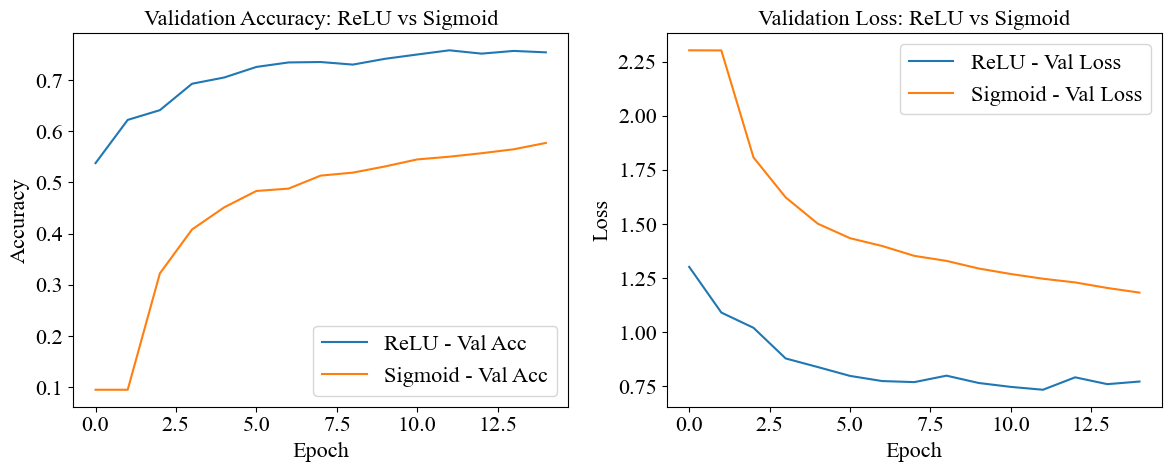

In [11]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(activation_histories['relu'].history['val_accuracy'], label='ReLU - Val Acc')
plt.plot(activation_histories['sigmoid'].history['val_accuracy'], label='Sigmoid - Val Acc')
plt.title("Validation Accuracy: ReLU vs Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(activation_histories['relu'].history['val_loss'], label='ReLU - Val Loss')
plt.plot(activation_histories['sigmoid'].history['val_loss'], label='Sigmoid - Val Loss')
plt.title("Validation Loss: ReLU vs Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
save_eps_or_pdf("relu_vs_sigmoid_comparison")
plt.show()